# Cryptocurrency EDA for Bitcoin (BTC), Ethereum (ETH), and Litecoin (LTC).
This analysis report performs Exploratory data analysis (EDA) on minute-level high-frequency trading data for Bitcoin (BTC), Ethereum (ETH), and Litecoin (LTC).
The analysis is mainly carried out in the following aspects
1. Price Performance Comparison: The prices of each currency are normalized to visually compare their relative performance from the starting point.
   
2. Volatility Analysis: Calculate and Plot the distribution of hourly returns (KDE Plot) for each currency to evaluate and compare its price volatility.
   
3. Correlation analysis: Create a price correlation Heatmap to quantify the synchrony of the price movements of different cryptocurrencies. 

In [1]:
import kagglehub
import os
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import pickle
import shutil

In [2]:
# Set the drawing style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7) 

## 1.Download the dataset

In [3]:
# Define the dataset identifier
dataset_handle = "tencars/392-crypto-currency-pairs-at-minute-resolution"

print("Starting to download dataset from Kaggle Hub...")
print(f"Dataset: {dataset_handle}")

# Use a try-except block to handle potential network errors
try:
    # kagglehub.dataset_download does the following:
    # 1. Connects to the Kaggle API for authentication.
    # 2. Finds the specified dataset and downloads it (usually a compressed file).
    # 3. Automatically extracts the compressed file to a local cache folder.
    # 4. Returns the full path to this cache folder.
    download_path = kagglehub.dataset_download(dataset_handle)
    
    print("\nDownload and extraction successful!")
    print(f"All files are saved at this path: {download_path}")

except Exception as e:
    print(f"\nDownload failed. Error: {e}")
    print("Please check your internet connection and Kaggle API configuration.")
    # If the download fails, you can set an alternative local path (if you have downloaded it manually before)
    download_path = None

# If the download was successful, we can list the files
if download_path:
    print("\n" + "="*50)
    print("Here are some of the CSV files in the extracted directory:")
    
    # Use os.listdir to get all filenames in the directory
    all_files = os.listdir(download_path)
    
    # Filter for CSV files
    csv_files = [f for f in all_files if f.endswith('.csv')]
    
    # Print the first 15 CSV files found
    for filename in sorted(csv_files)[:15]:
        print(f"  - {filename}")
    
    if len(csv_files) > 15:
        print("  - ... and more files")
        

# Ensure download_path is valid
if download_path:
    # Define the target directory
    target_dir = os.path.join('data', 'crypto')
    
    # Create the target directory
    os.makedirs(target_dir, exist_ok=True)
    
    print(f"\nPreparing to copy files from the cache directory to the project directory: {target_dir}")
    
    # Get the full source path for all CSV files to be copied
    csv_files_to_copy = [os.path.join(download_path, f) for f in os.listdir(download_path) if f.endswith('.csv')]
    
    # Loop through and copy each file
    for src_file_path in csv_files_to_copy:
        shutil.copy(src_file_path, target_dir)
        
    print(f"Successfully copied {len(csv_files_to_copy)} files!")
    
    print("\nNow, please refresh the file explorer on the left side of your VS Code. You should see all the CSV files in the 'data/crypto' folder.")

Starting to download dataset from Kaggle Hub...
Dataset: tencars/392-crypto-currency-pairs-at-minute-resolution

Download and extraction successful!
All files are saved at this path: /Users/wangxinman/.cache/kagglehub/datasets/tencars/392-crypto-currency-pairs-at-minute-resolution/versions/1231

Here are some of the CSV files in the extracted directory:
  - 1inch-usd.csv
  - 1inch-ust.csv
  - 1inch_usd.csv
  - 1inch_ust.csv
  - 1inchusd.csv
  - 1inchust.csv
  - aaabbb.csv
  - aave-usd.csv
  - aave-ust.csv
  - aave_usd.csv
  - aave_ust.csv
  - aavef0_ustf0.csv
  - aavef0ustf0.csv
  - aaveusd.csv
  - aaveust.csv
  - ... and more files

Preparing to copy files from the cache directory to the project directory: data/crypto
Successfully copied 984 files!

Now, please refresh the file explorer on the left side of your VS Code. You should see all the CSV files in the 'data/crypto' folder.


In [4]:
def load_and_preprocess_with_duckdb(file_path, resample_rule='1h'):
    """
    Loads data from a CSV file using DuckDB, and performs resampling and preprocessing.
    """
    coin_name = os.path.basename(file_path).replace('.csv', '')
    print(f"\n>>>>> Starting to process with DuckDB: {coin_name.upper()} <<<<<")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return None

    # DuckDB SQL Query
    # Core idea:
    # 1. read_csv_auto('{file_path}'): Directly reads data from the CSV file.
    # 2. to_timestamp(time / 1000): Converts Unix timestamp (in milliseconds) to DuckDB's timestamp type.
    # 3. date_trunc('hour', ...): This is DuckDB's way to resample by hour. It truncates the time to the beginning of the hour.
    # 4. GROUP BY time_bucket: Groups rows by the truncated time bucket.
    # 5. arg_max/arg_min: A clever trick to get the first/last value within a group.
    #    - arg_max(close, to_timestamp(time / 1000)) gets the 'close' value from the row with the latest timestamp in the group (i.e., 'last').
    #    - arg_min(open, to_timestamp(time / 1000)) gets the 'open' value from the row with the earliest timestamp in the group (i.e., 'first').
    query = f"""
    SELECT
        date_trunc('hour', to_timestamp(time / 1000)) AS time_bucket,
        arg_min(open, to_timestamp(time / 1000)) AS open,
        max(high) AS high,
        min(low) AS low,
        arg_max(close, to_timestamp(time / 1000)) AS close,
        sum(volume) AS volume
    FROM read_csv_auto(
        '{file_path}', 
        header=true, 
        columns={'time': 'BIGINT', 'open': 'DOUBLE', 'high': 'DOUBLE', 'low': 'DOUBLE', 'close': 'DOUBLE', 'volume': 'DOUBLE'}
    )
    WHERE time > 0 -- A simple validity check
    GROUP BY time_bucket
    ORDER BY time_bucket;
    """
    
    print("Executing DuckDB query (handling millisecond timestamps)...")

    # Execute the query and convert the result directly to a Pandas DataFrame
    try:
        df_resampled = duckdb.query(query).to_df()
    except Exception as e:
        print(f"DuckDB query failed: {e}")
        return None

    # Set the time column as the index for easier subsequent operations
    df_resampled.set_index('time_bucket', inplace=True)
    
    print(f"Processing complete. Obtained {len(df_resampled)} hourly records.")
    
    return df_resampled

In [5]:
duckdb.execute(
"""
create or replace table btc_raw as (
    select *,'btc' as coin_name
    from read_csv_auto(
    'data/crypto/btcusd.csv',
    header=true,
    columns={'time': 'BIGINT', 'open': 'DOUBLE', 'high': 'DOUBLE', 'low': 'DOUBLE', 'close': 'DOUBLE', 'volume': 'DOUBLE'}
    )
)
""")

In [6]:
duckdb.execute(
"""
create or replace table eth_raw as (
    select *,'eth' as coin_name
    from read_csv_auto(
    'data/crypto/ethusd.csv',
    header=true,
    columns={'time': 'BIGINT', 'open': 'DOUBLE', 'high': 'DOUBLE', 'low': 'DOUBLE', 'close': 'DOUBLE', 'volume': 'DOUBLE'}
    )
)
""")

In [7]:
duckdb.execute(
"""
create or replace table ltc_raw as (
    select *,'ltc' as coin_name
    from read_csv_auto(
    'data/crypto/ltcusd.csv',
    header=true,
    columns={'time': 'BIGINT', 'open': 'DOUBLE', 'high': 'DOUBLE', 'low': 'DOUBLE', 'close': 'DOUBLE', 'volume': 'DOUBLE'}
  )
  )
  """)

In [8]:
duckdb.execute("""
    CREATE OR REPLACE TABLE crypto_data as (
        SELECT *, 'btc' as coin_name from btc_raw
        UNION ALL
        SELECT *, 'eth' as coin_name from eth_raw
        UNION ALL 
        SELECT *, 'ltc' as coin_name from ltc_raw
    );
""")

In [9]:
#Keeping the raw data for all currencies in one place makes it easier to query it later, for example if you want to query the prices for all currencies at one time
duckdb.query("select date_trunc('hour', to_timestamp(time / 1000)) AS time_bucket, coin_name,arg_min(open, to_timestamp(time / 1000)) AS open,arg_max(close, to_timestamp(time / 1000)) AS close,sum(volume) AS volume, max(high), min(low) from crypto_data group by 1,2")

┌──────────────────────────┬───────────┬──────────────┬──────────────┬────────────────────┬──────────────┬──────────┐
│       time_bucket        │ coin_name │     open     │    close     │       volume       │  max(high)   │ min(low) │
│ timestamp with time zone │  varchar  │    double    │    double    │       double       │    double    │  double  │
├──────────────────────────┼───────────┼──────────────┼──────────────┼────────────────────┼──────────────┼──────────┤
│ 2015-01-07 01:00:00+08   │ btc       │       274.89 │       276.85 │      1306.10636532 │        277.0 │    274.4 │
│ 2015-01-07 08:00:00+08   │ btc       │       288.36 │       284.58 │ 1356.3361516599998 │       288.78 │    285.1 │
│ 2015-01-08 06:00:00+08   │ btc       │       296.64 │        297.9 │ 1475.9650740199995 │       298.29 │   296.32 │
│ 2015-01-08 09:00:00+08   │ btc       │       297.12 │        295.0 │       720.34695663 │        297.0 │    295.0 │
│ 2015-01-10 05:00:00+08   │ btc       │       293.85 │ 

## 2.Exploratory Data Analysis (EDA) ##

In [10]:
# 1. Execute aggregation query and convert it to a Pandas DataFrame with .to_df()
query = """
SELECT 
    date_trunc('hour', to_timestamp(time / 1000)) AS time_bucket, 
    coin_name,
    arg_min(open, to_timestamp(time / 1000)) AS open,
    max(high) AS high,
    min(low) AS low,
    arg_max(close, to_timestamp(time / 1000)) AS close,
    sum(volume) AS volume
FROM 
    crypto_data 
GROUP BY 
    1, 2
ORDER BY
    1, 2;
"""
hourly_df = duckdb.query(query).to_df()

# 2. Check the data
print("Data loaded into DataFrame, here are the first few rows:")
print(hourly_df.head())

print("\nData information:")
hourly_df.info()

Data loaded into DataFrame, here are the first few rows:
                time_bucket coin_name      open       high       low  \
0 2013-04-01 08:00:00+08:00       btc  93.25000  100.00000  93.03001   
1 2013-04-01 09:00:00+08:00       btc  93.37999   93.48797  93.10001   
2 2013-04-01 10:00:00+08:00       btc  93.17000   93.74000  93.10999   
3 2013-04-01 11:00:00+08:00       btc  93.80000   93.80000  92.50000   
4 2013-04-01 12:00:00+08:00       btc  93.15501   93.15503  93.15503   

      close      volume  
0  93.10000  345.583889  
1  93.10000   45.243335  
2  93.74000  466.311420  
3  92.70002   96.316180  
4  93.15501    5.000000  

Data information:
<class 'pandas.DataFrame'>
RangeIndex: 235402 entries, 0 to 235401
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype                         
---  ------       --------------   -----                         
 0   time_bucket  235402 non-null  datetime64[us, Asia/Hong_Kong]
 1   coin_name    235402 non-null  str


Generating Chart 1: Normalized Price Performance...


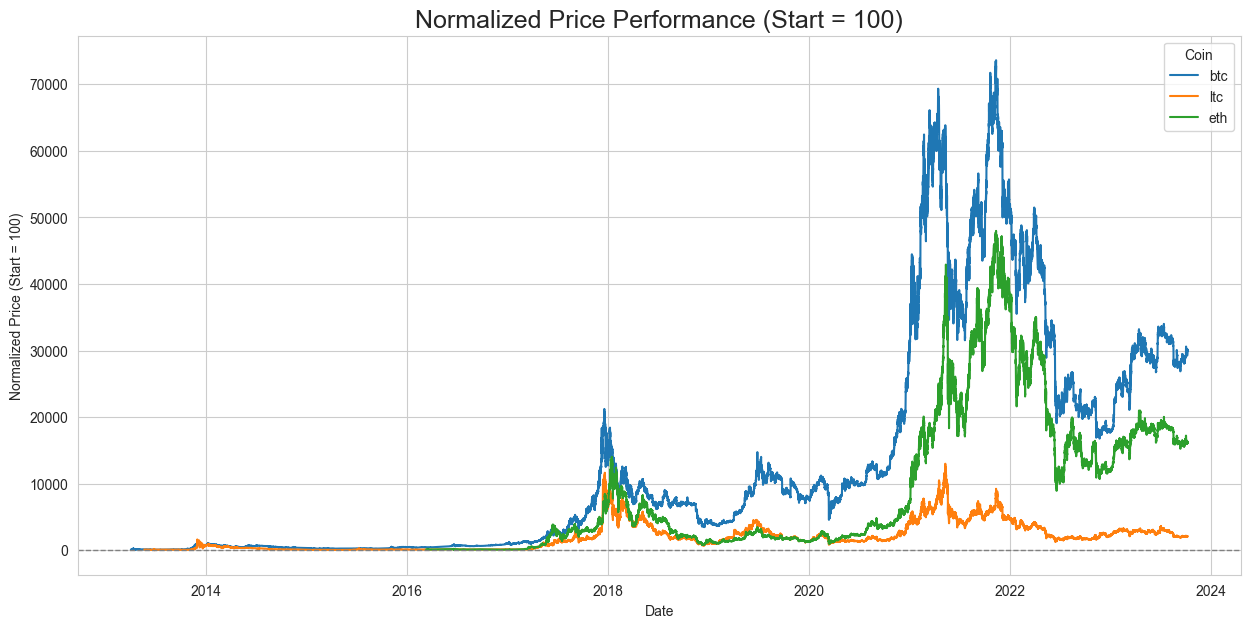

In [11]:
# Normalized Price Comparison (Performance Comparison)
# We will set the initial price of each coin to 100 to observe their performance relative to the starting point.
# This is a standard method for comparing the performance of different assets.


print("\nGenerating Chart 1: Normalized Price Performance...")
# For each coin, get its first closing price
first_prices = hourly_df.groupby('coin_name')['close'].transform('first')
# Create a new column to store the normalized price
hourly_df['normalized_close'] = (hourly_df['close'] / first_prices) * 100

plt.figure()
sns.lineplot(
    data=hourly_df, 
    x='time_bucket', 
    y='normalized_close', 
    hue='coin_name'
)
plt.title('Normalized Price Performance (Start = 100)', fontsize=18)
plt.ylabel('Normalized Price (Start = 100)')
plt.xlabel('Date')
plt.axhline(100, color='gray', linestyle='--', linewidth=1) 
plt.legend(title='Coin')
plt.show()

### Observations:
All three cryptocurrencies exhibit high price volatility. The chart clearly illustrates two major "bull-bear cycles":

·The 2017-2018 Cycle: In 2017, the prices of all three assets experienced explosive growth, forming a sharp peak, followed by a rapid crash in 2018.

·The 2020-2022 Cycle: Beginning in late 2020, the market entered a bull run of an even larger scale. Prices surged once again, reaching new all-time highs in 2021 (the chart displays a "double-top" pattern, with peaks in the first and second halves of the year). Subsequently, the market entered another deep bear market in 2022.

Bitcoin (BTC): As the market leader, Bitcoin has demonstrated the most robust long-term growth. During both bull cycles, its normalized price reached the highest points. This was particularly evident during the 2021 bull market, where its normalized price surpassed 70,000, signifying an increase of over 700-fold from its starting point. This indicates that Bitcoin was the best-performing long-term investment asset over the entire period under review.

Ethereum (ETH): Ethereum (ETH) launched later than Bitcoin and Litecoin (circa 2015) but rose to prominence rapidly during the 2017 bull market. Particularly noteworthy is its performance in the 2020-2021 bull run, where its growth trajectory was remarkably steep, with its normalized performance at one point closely trailing that of Bitcoin.

Litecoin (LTC): As one of the early "altcoins," Litecoin (LTC)'s growth has significantly lagged behind that of Bitcoin and Ethereum. The performance gap between it and the two leading assets has progressively widened. This suggests that as the market matures, capital and attention are increasingly concentrating on top-tier assets like BTC and ETH, which possess stronger network effects and more developed application ecosystems.


Calculating hourly returns for each coin...

Generating Chart: Hourly Returns Distribution Comparison...


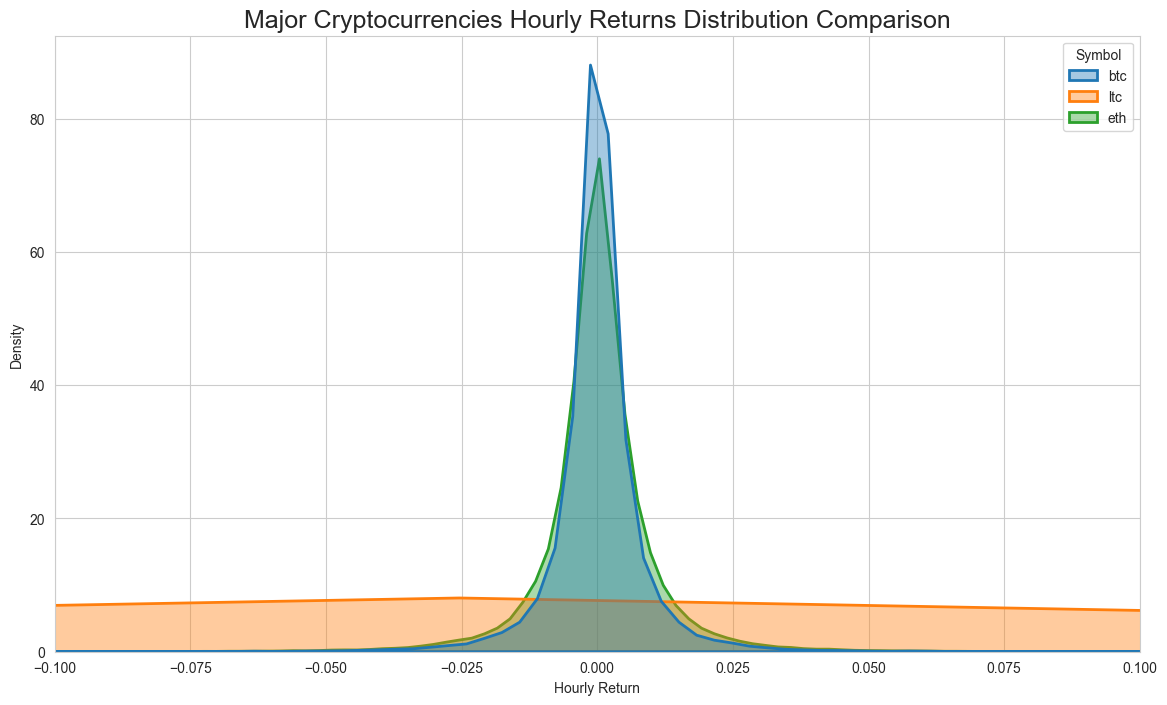

In [12]:
# Analysis 2: Hourly Returns Distribution Comparison
# To understand volatility, we can look at the distribution of hourly returns.
# A return is the percentage change in price from one period to the next.
# We will plot a Kernel Density Estimate (KDE) plot, which is a smoothed version of a histogram,
# to compare the return distributions of different coins.

print("\nCalculating hourly returns for each coin...")
# To analyze returns, we first need to calculate them.
# We use .groupby('coin_name') to ensure the calculation is done independently for each coin.
# .pct_change() calculates the percentage change between the current and prior element.
# This gives us the hourly return for the 'close' price.
hourly_df['hourly_return'] = hourly_df.groupby('coin_name')['close'].pct_change()

print("\nGenerating Chart: Hourly Returns Distribution Comparison...")

# Create a figure and axes for the plot for better control
fig, ax = plt.subplots(figsize=(14, 8))

# Use seaborn's kdeplot to create the distribution plot.
# This function is perfect for replicating the chart you provided.
sns.kdeplot(
    data=hourly_df,
    x='hourly_return',
    hue='coin_name',
    fill=True,          # Fills the area under the curve, like in the example image.
    common_norm=False,  # Important: Normalizes each curve independently so their shapes are comparable.
    alpha=0.4,          # Sets transparency so overlapping areas are visible.
    linewidth=2,
    ax=ax               # Specifies that the plot should be drawn on our defined axes.
)

# Set the title and labels to match the desired output
ax.set_title('Major Cryptocurrencies Hourly Returns Distribution Comparison', fontsize=18)
ax.set_xlabel('Hourly Return')
ax.set_ylabel('Density')

# To better match the example image, we can set the x-axis limits
# This "zooms in" on the area where most returns occur (-10% to +10%).
ax.set_xlim(-0.1, 0.1)

# The legend is automatically generated by the 'hue' parameter, but we can customize its title.
# We get the legend handle from the axes and set its title.
ax.get_legend().set_title('Symbol')

plt.show()



### Observations:
The short-term price stability of BTC and ETH is similar and high, with little volatility most of the time. LTC prices are more prone to larger range movements at the hourly level.


Generating Chart 3: Price Correlation Heatmap...
Correlation Matrix:
coin_name       btc       eth       ltc
coin_name                              
btc        1.000000  0.935200  0.788841
eth        0.935200  1.000000  0.661726
ltc        0.788841  0.661726  1.000000


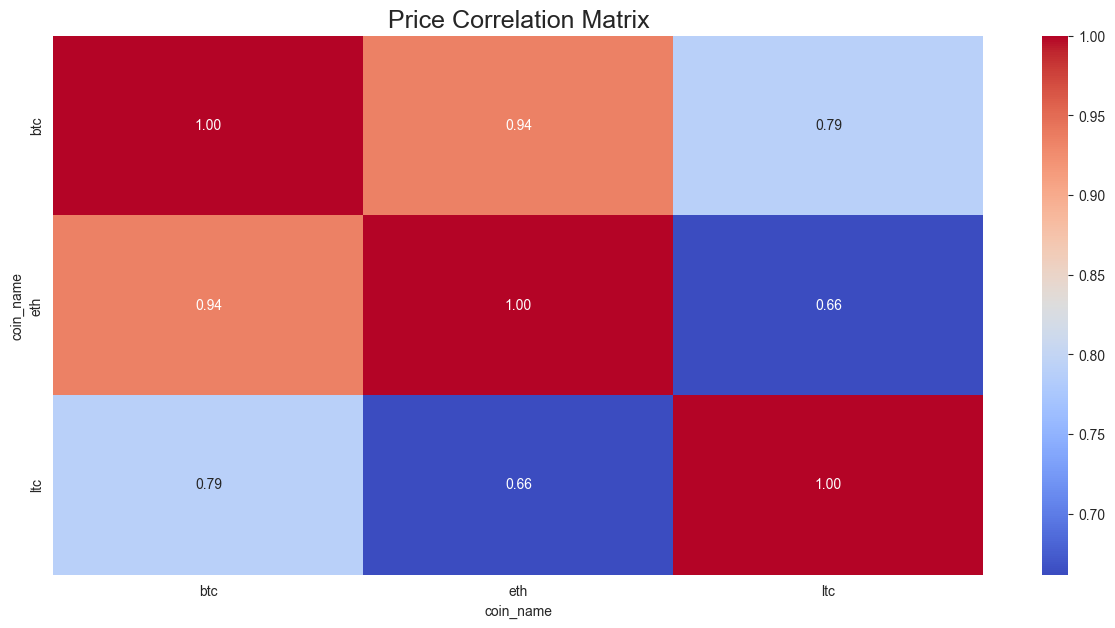

In [13]:
# Chart 3: Price Correlation Heatmap
# This chart shows the degree to which the price movements of different coins are synchronized.
# A value of 1 means their movements are perfectly synchronized; -1 means their movements are completely opposite.


print("\nGenerating Chart 3: Price Correlation Heatmap...")
# To calculate the correlation, we need to convert the data from a "long" format to a "wide" format
wide_prices_df = hourly_df.pivot(index='time_bucket', columns='coin_name', values='close')

# Now, calculate the correlation matrix on this wide-format DataFrame
correlation_matrix = wide_prices_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

plt.figure()
# Use seaborn's heatmap function to visualize this matrix
sns.heatmap(
    correlation_matrix, 
    annot=True,       
    cmap='coolwarm', 
    fmt=".2f"        
)
plt.title('Price Correlation Matrix', fontsize=18)
plt.show()


### Observations:
The prices of btc and ltc are strongly positively correlated. Each currency has a significant positive relationship with the other, meaning that their market prices tend to "go up and down together.